In [30]:
from sklearn. linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [15]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha=0.001: 20918648.88982561
MSE for alpha=0.1: 20918648.88982561
MSE for alpha=1: 20918648.88982561
MSE for alpha=2: 20918648.88982561
MSE for alpha=5: 20918648.88982561
MSE for alpha=10: 20918648.88982561
MSE for alpha=20: 20918648.88982561
MSE for alpha=30: 20918648.88982561
MSE for alpha=40: 20918648.88982561
MSE for alpha=50: 20918648.88982561
MSE for alpha=100: 20918648.88982561


<Axes: >

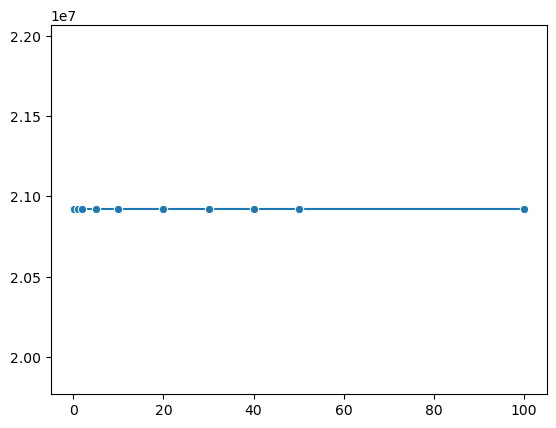

In [23]:
import seaborn as sns

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=0.5)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha={a}:", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")

In [31]:
from sklearn. linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha:", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("r2 :", r2)

best alpha: 0.001
MSE : 20922599.87103596
r2 : 0.8652317499151699
